In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import PercentFormatter
from statsmodels.stats.weightstats import DescrStatsW

plt.style.use('seaborn-v0_8')

In [2]:
data = pd.read_csv('smaller.csv', dtype={'SOCP': str})
data['inc2024'] = data.PINCP * data.ADJINC / 1_000_000
print(data.shape, data.PWGTP.sum())

data = data.dropna(subset=['PWGTP', 'ADJINC', 'PINCP'])
print(data.shape, data.PWGTP.sum())

data = data[data.inc2024 > 0]
print(data.shape, data.PWGTP.sum())

(3422888, 7) 340110990
(2912790, 7) 280613270
(2556439, 7) 245168158


In [83]:
breaks = [0.25, 0.5, 0.75]
breaks = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.96, 0.97, 0.98, 0.99]
breaks = [0.25, 0.5, 0.75, 0.85, 0.9, 0.94, 0.96, 0.97, 0.98, 0.99]
ages = [10 * (index + 2) for index in range(6)]
quantiles = []
for index in range(6):
    subset = data[data.AGEP // 10 == (index + 2)]
    subset = subset.sort_values('inc2024')
    d = DescrStatsW(subset.inc2024, weights=subset.PWGTP)
    quantiles.append(d.quantile(breaks))

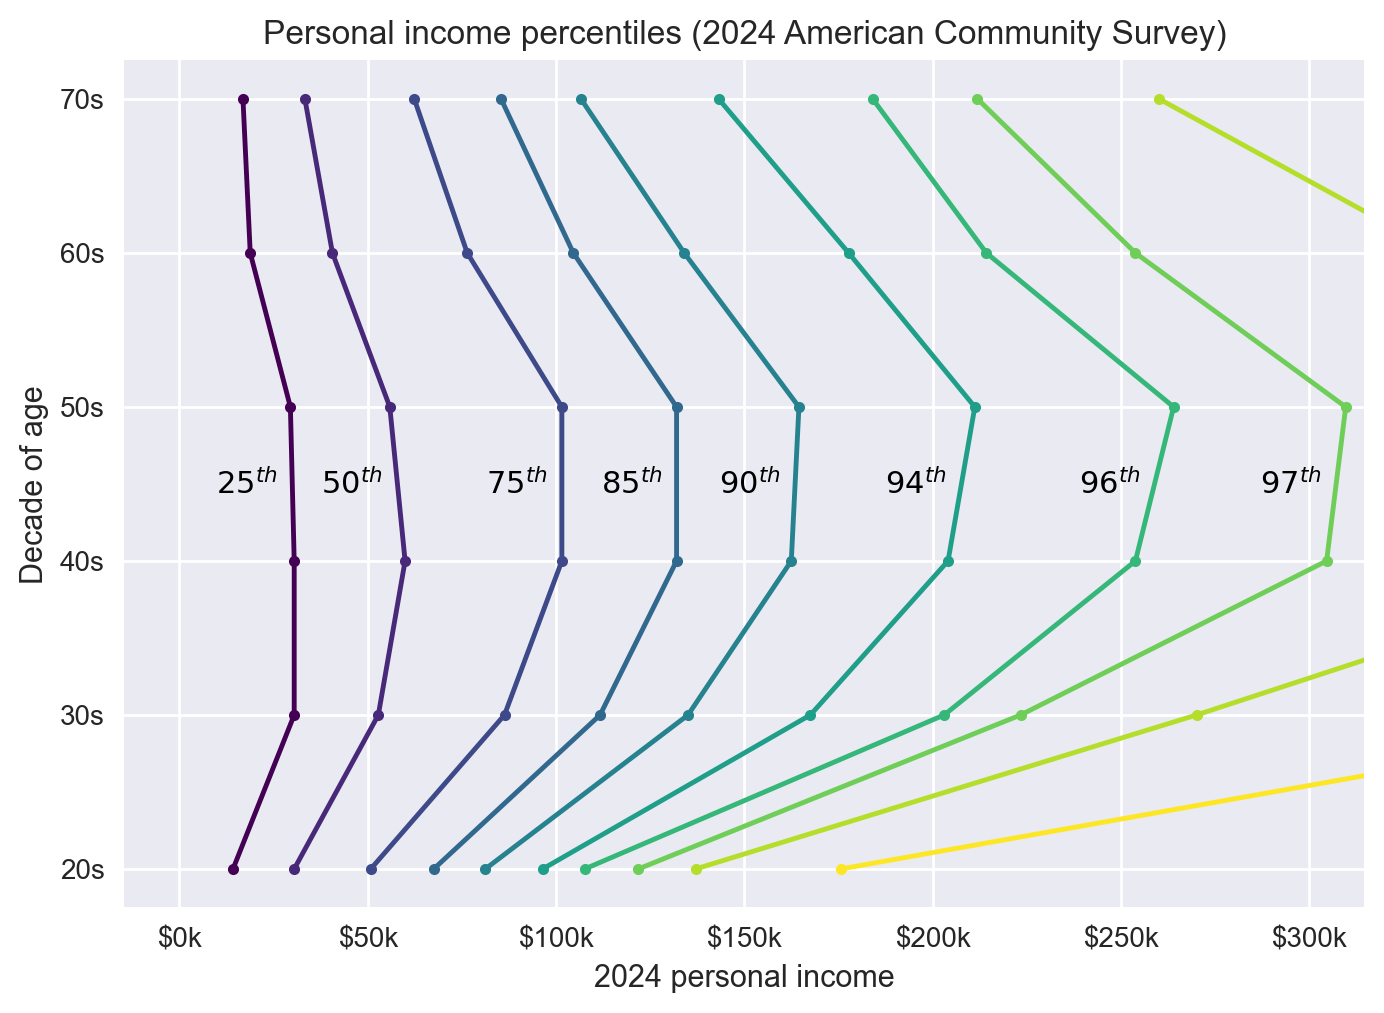

In [85]:
results = np.stack(quantiles)
#results[results > 300_000] = None

cmap = plt.get_cmap('viridis')  # 'viridis', 'plasma', 'cividis', etc.
colors = cmap(np.linspace(0, 1, len(breaks)))#[::-1]

for index, series in enumerate(results.T):
    plt.plot(series, ages, '-o', markersize=4, color=colors[index])
    if (series[2] + series[3]) / 2 < 330_000:
        plt.text(
            x=(series[2] + series[3]) / 2 - 12_000,
            y=sum(plt.ylim()) / 2,     # centered vertically
            s=f'${int(breaks[index]*100)}^{{th}}$',
            ha='center', va='center',
            color='black', fontsize=11#, fontweight='bold'
)

left, right = plt.xlim()
plt.xlim(right=300_000 - left)
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}k'))
plt.xlabel('2024 personal income')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}s'))
plt.ylabel('Decade of age')
plt.title('Personal income percentiles (2024 American Community Survey)')

plt.show()

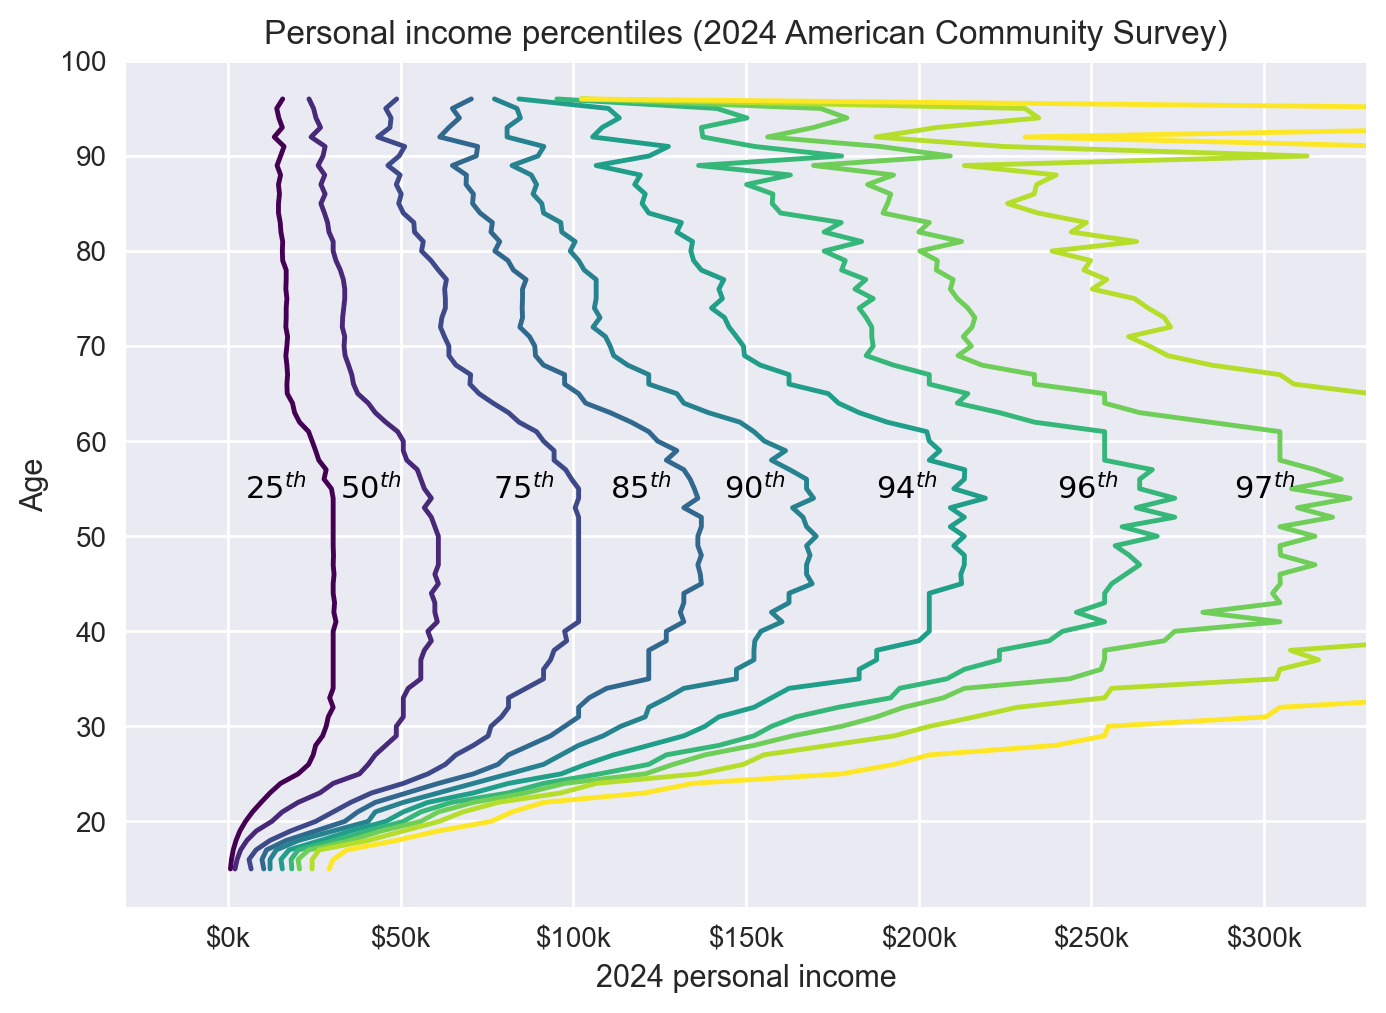

In [95]:
breaks = [0.25, 0.5, 0.75]
breaks = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.96, 0.97, 0.98, 0.99]
breaks = [0.25, 0.5, 0.75, 0.85, 0.9, 0.94, 0.96, 0.97, 0.98, 0.99]
ages = list(range(data.AGEP.min(), data.AGEP.max() + 1))
quantiles = []
for index in ages:
    subset = data[data.AGEP == index]
    subset = subset.sort_values('inc2024')
    d = DescrStatsW(subset.inc2024, weights=subset.PWGTP)
    quantiles.append(d.quantile(breaks))

results = np.stack(quantiles)
#results[results > 300_000] = None

cmap = plt.get_cmap('viridis')  # 'viridis', 'plasma', 'cividis', etc.
colors = cmap(np.linspace(0, 1, len(breaks)))#[::-1]

for index, series in enumerate(results.T):
    plt.plot(series, ages, color=colors[index])  # '-o', markersize=4, 
    if (series[40] + series[41]) / 2 < 330_000:
        plt.text(
            x=(series[40] + series[41]) / 2 - 15_000,
            y=55, #sum(plt.ylim()) / 2,     # centered vertically
            s=f'${int(breaks[index]*100)}^{{th}}$',
            ha='center', va='center',
            color='black', fontsize=11#, fontweight='bold'
)

left, right = plt.xlim()
plt.xlim(right=300_000 - left)
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}k'))
plt.xlabel('2024 personal income')
#plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}s'))
plt.ylabel('Age')
plt.title('Personal income percentiles (2024 American Community Survey)')

plt.show()

In [90]:
len(series)

82